# 05 - OceanEmbed v2: CNN encoder + MLP decoder

**v2 changes** (v1 lost to the Random Forest baseline: 0.924 vs 0.849 RMSE overall, and was
especially weak in deep water - 0.665 vs 0.432):

1. **Flatten instead of GlobalAveragePooling2D** in the model architecture - GAP was throwing
   away spatial arrangement within the 5x5 patch, keeping only a per-channel average. See
   `src/models/oceanembed_model.py` for details.
2. **A skip connection to the center pixel** - guarantees the model has at least the same
   point-wise information the Random Forest baseline used, so the conv branch only has to
   learn the *additional* value of spatial context, not reconstruct the point reading from
   scratch.
3. **Per-depth target normalization** (new in this notebook, see below) - shallow
   temperatures range ~0-30 C, deep ones ~5-10 C. Training on raw values means shallow
   errors dominate the loss simply because they're numerically larger, likely starving the
   deep and thermocline depths of gradient signal. This is probably the biggest single factor
   behind the CNN's earlier deep-water weakness.
4. **Deeper, regularized decoder + a learning-rate schedule**, since the model now has more
   to work with and needs to use it without overfitting.

This is the model that needs to beat the Random Forest's 0.849 C RMSE - not just overall, but
specifically in the deep-ocean and thermocline bands where v1 struggled most.

In [1]:
import re
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.oceanembed_model import build_oceanembed_model

PAIRS_DIR = PROJECT_ROOT / "data" / "processed" / "pairs"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pair_files = sorted(PAIRS_DIR.glob("pairs_*.nc"))
if not pair_files:
    raise FileNotFoundError(f"No paired files found in {PAIRS_DIR} - run pairing.py first.")

print(f"Found {len(pair_files)} paired daily files")

Found 10 paired daily files


## Load every daily pairs file

Unlike the Random Forest baseline, the **full 5x5 patch** is kept here (not just the center
pixel) - that spatial context is the entire point of using a CNN.

In [2]:
DATE_RE = re.compile(r"pairs_(\d{4}-\d{2}-\d{2})\.nc")

all_patches = []
all_profiles = []
all_valid = []
all_time = []

for path in pair_files:
    match = DATE_RE.search(path.name)
    date_str = match.group(1) if match else None

    with xr.open_dataset(path) as ds:
        n = ds.sizes["sample"]
        if n == 0:
            continue

        all_patches.append(ds["patch"].values)       # (n, channel, 5, 5)
        all_profiles.append(ds["profile"].values)     # (n, depth)
        all_valid.append(ds["valid_mask"].values)      # (n, depth)
        all_time.append(np.full(n, date_str))

        channel_names = list(ds["channel"].values)
        depth_values = ds["depth"].values

patches = np.concatenate(all_patches, axis=0)
profiles = np.concatenate(all_profiles, axis=0)
valid_mask = np.concatenate(all_valid, axis=0)
time_str = np.concatenate(all_time, axis=0)

print("Channels:", channel_names)
print("Depths:", depth_values)
print("Patches shape (n, channel, py, px):", patches.shape)
print("Profiles shape:", profiles.shape)

Channels: [np.str_('sst'), np.str_('sss'), np.str_('sla'), np.str_('ugos'), np.str_('vgos'), np.str_('eastward_wind'), np.str_('northward_wind')]
Depths: [   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]
Patches shape (n, channel, py, px): (21279, 7, 5, 5)
Profiles shape: (21279, 15)


In [3]:
# Keep only samples with a fully valid profile (pairing.py's default already
# enforces this, but guard against re-running with looser settings).
complete = valid_mask.all(axis=1)
print(f"Samples with a complete 15-depth profile: {complete.sum():,} / {len(complete):,}")

patches = patches[complete]
profiles = profiles[complete]
time_str = time_str[complete]

# Keras/TensorFlow's Conv2D expects channels LAST: (batch, height, width, channel).
# pairing.py saved (sample, channel, py, px) - transpose once, here.
patches = np.transpose(patches, (0, 2, 3, 1)).astype("float32")
profiles = profiles.astype("float32")

print("Patches ready for the model:", patches.shape, "(sample, height, width, channel)")

Samples with a complete 15-depth profile: 21,279 / 21,279
Patches ready for the model: (21279, 5, 5, 7) (sample, height, width, channel)


## Normalize inputs

Each channel has a very different scale (temperature in \u00b0C, salinity in PSU, current
speed in m/s, ...). Normalize per-channel using **training-set statistics only** - the
validation and test sets must never influence this, or the split isn't a real holdout.

In [4]:
time_dt = pd.to_datetime(time_str)
unique_dates = np.sort(pd.unique(time_dt))
n_dates = len(unique_dates)

TRAIN_FRAC, VAL_FRAC = 0.70, 0.15
train_cutoff = unique_dates[int(n_dates * TRAIN_FRAC)]
val_cutoff = unique_dates[int(n_dates * (TRAIN_FRAC + VAL_FRAC))]

train_mask = time_dt < train_cutoff
val_mask = (time_dt >= train_cutoff) & (time_dt < val_cutoff)
test_mask = time_dt >= val_cutoff

X_train, y_train = patches[train_mask], profiles[train_mask]
X_val, y_val = patches[val_mask], profiles[val_mask]
X_test, y_test = patches[test_mask], profiles[test_mask]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train dates:", time_dt[train_mask].min(), "to", time_dt[train_mask].max())
print("Test dates: ", time_dt[test_mask].min(), "to", time_dt[test_mask].max())

Train: (14967, 5, 5, 7)  Val: (2100, 5, 5, 7)  Test: (4212, 5, 5, 7)
Train dates: 2021-01-01 00:00:00 to 2021-05-31 00:00:00
Test dates:  2021-06-10 00:00:00 to 2021-06-15 00:00:00


In [5]:
# Per-channel mean/std from the TRAINING set only.
channel_mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
channel_std = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-6

X_train_norm = (X_train - channel_mean) / channel_std
X_val_norm = (X_val - channel_mean) / channel_std
X_test_norm = (X_test - channel_mean) / channel_std

np.savez(
    MODELS_DIR / "oceanembed_normalization.npz",
    mean=channel_mean, std=channel_std, channels=channel_names,
)
print("Saved normalization stats to models/oceanembed_normalization.npz")
print("(the serving/ prediction code must apply the SAME mean/std before calling the model)")

Saved normalization stats to models/oceanembed_normalization.npz
(the serving/ prediction code must apply the SAME mean/std before calling the model)


## Normalize targets (per depth) - the key fix for the deep-ocean weakness

Shallow depths have a much larger temperature range than deep ones. Training on raw C values
means the loss is dominated by whichever depths have the largest absolute errors in absolute
terms - which is the shallow depths, just because the numbers are bigger, not because they're
more important. Z-scoring each of the 15 depth columns independently (using TRAINING set
statistics only) puts every depth on an equal footing during training.

Predictions are converted back to Celsius (denormalized) before any RMSE/MAE is reported, so
every number in the evaluation section below is still in real, interpretable units - only the
training loss operates on the normalized scale.

In [6]:
# Per-depth mean/std from the TRAINING set only - same principle as the
# per-channel input normalization above, just applied to the target instead.
depth_mean = y_train.mean(axis=0, keepdims=True)   # shape (1, 15)
depth_std = y_train.std(axis=0, keepdims=True) + 1e-6

y_train_norm = (y_train - depth_mean) / depth_std
y_val_norm = (y_val - depth_mean) / depth_std
# y_test is deliberately NOT normalized - it stays in real Celsius so the
# evaluation section further down reports true RMSE/MAE, not normalized units.

np.savez(
    MODELS_DIR / "oceanembed_target_normalization.npz",
    mean=depth_mean, std=depth_std, depths=depth_values,
)
print("Saved per-depth target normalization to models/oceanembed_target_normalization.npz")
print("(the serving/ prediction code must invert this - multiply by std, add mean - on the")
print(" model's raw output before returning a temperature to the user)")

Saved per-depth target normalization to models/oceanembed_target_normalization.npz
(the serving/ prediction code must invert this - multiply by std, add mean - on the
 model's raw output before returning a temperature to the user)


## Build and train the model

In [7]:
model = build_oceanembed_model(
    patch_size=patches.shape[1],
    n_channels=patches.shape[3],
    n_depths=profiles.shape[1],
)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "OceanEmbed_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ surface_patch       │ (None, 5, 5, 7)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 5, 5, 16)  │      1,024 │ surface_patch[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 5, 5, 16)  │         64 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 5, 5, 32)  │      4,640 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 5, 32)  │        128 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_flatten     │ (None, 800)       │          0 │ batch_normalizat… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding (Dense)   │ (None, 64)        │     51,264 │ encoder_flatten[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ center_pixel_skip   │ (None, 7)         │          0 │ surface_patch[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_plus_skip │ (None, 71)        │          0 │ embedding[0][0],  │
│ (Concatenate)       │                   │            │ center_pixel_ski… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense1      │ (None, 128)       │      9,216 │ embedding_plus_s… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout1    │ (None, 128)       │          0 │ decoder_dense1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense2      │ (None, 64)        │      8,256 │ decoder_dropout1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout2    │ (None, 64)        │          0 │ decoder_dense2[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense3      │ (None, 32)        │      2,080 │ decoder_dropout2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout3    │ (None, 32)        │          0 │ decoder_dense3[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_profile       │ (None, 15)        │        495 │ decoder_dropout3… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,167 (301.43 KB)

 Trainable params: 77,071 (301.06 KB)

 Non-trainable params: 96 (384.00 B)

In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6),
    ModelCheckpoint(
        MODELS_DIR / "oceanembed_best.keras",
        monitor="val_loss", save_best_only=True,
    ),
]

history = model.fit(
    X_train_norm, y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=200,
    batch_size=256,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.6593 - mae: 0.6335 - val_loss: 0.6550 - val_mae: 0.6862 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3675 - mae: 0.4638 - val_loss: 0.4362 - val_mae: 0.5431 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2798 - mae: 0.4039 - val_loss: 0.3062 - val_mae: 0.4339 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2367 - mae: 0.3708 - val_loss: 0.2415 - val_mae: 0.3764 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2133 - mae: 0.3524 - val_loss: 0.2062 - val_mae: 0.3341 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1957 - mae: 0.3374 - val_loss: 0.1942 - val_mae: 0.3190 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1852 - mae: 0.3271 - val_loss: 0.1889 - val_mae: 0.3085 - learning_rate: 0.0010
Epoch 

In [9]:
model.save(MODELS_DIR / "oceanembed_final.keras")
print("Final model saved.")

Final model saved.


## Evaluate - overall, by depth band, and per-depth curve

Same methodology as both baselines, so all three are directly comparable.

In [10]:
y_pred_norm = model.predict(X_test_norm, batch_size=256)

# Undo the per-depth normalization so every metric below is in real Celsius,
# comparable directly to both baselines.
y_pred = y_pred_norm * depth_std + depth_mean

overall_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
overall_mae = mean_absolute_error(y_test, y_pred)
overall_r2 = r2_score(y_test, y_pred)

print("OceanEmbed v2 CNN Results (all depths combined)")
print("-----------------------------------------------")
print("RMSE:", overall_rmse)
print("MAE :", overall_mae)
print("R\u00b2  :", overall_r2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
OceanEmbed v2 CNN Results (all depths combined)
-----------------------------------------------
RMSE: 0.9481984372953046
MAE : 0.6628920435905457
R²  : 0.5751915574073792


In [11]:
depth_bins = [
    ("Shallow (0-100 m)", 0, 100),
    ("Thermocline (100-300 m)", 100, 300),
    ("Deep (300-1000 m)", 300, 1000),
]

print(f"{'Band':<25}{'RMSE':>10}{'MAE':>10}{'R\u00b2':>10}")
print("-" * 55)
for label, lo, hi in depth_bins:
    depth_idx = np.where((depth_values >= lo) & (depth_values <= hi))[0]
    band_rmse = np.sqrt(mean_squared_error(y_test[:, depth_idx], y_pred[:, depth_idx]))
    band_mae = mean_absolute_error(y_test[:, depth_idx], y_pred[:, depth_idx])
    band_r2 = r2_score(y_test[:, depth_idx], y_pred[:, depth_idx])
    print(f"{label:<25}{band_rmse:>10.3f}{band_mae:>10.3f}{band_r2:>10.3f}")

Band                           RMSE       MAE        R²
-------------------------------------------------------
Shallow (0-100 m)             0.851     0.591     0.548
Thermocline (100-300 m)       1.307     1.020     0.456
Deep (300-1000 m)             0.686     0.465     0.725


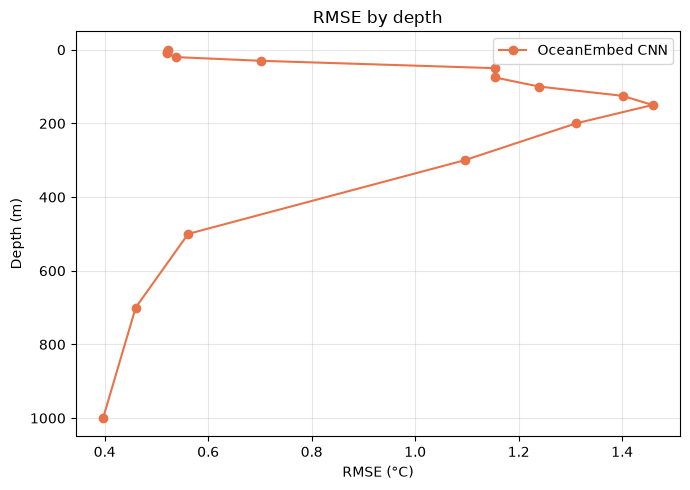

In [12]:
per_depth_rmse = np.sqrt(np.mean((y_test - y_pred) ** 2, axis=0))

plt.figure(figsize=(7, 5))
plt.plot(per_depth_rmse, depth_values, marker="o", color="#E8734A", label="OceanEmbed CNN")
plt.gca().invert_yaxis()
plt.xlabel("RMSE (\u00b0C)")
plt.ylabel("Depth (m)")
plt.title("RMSE by depth")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

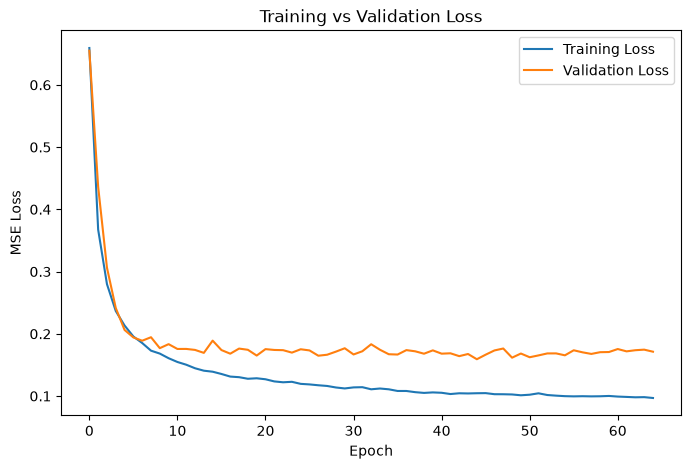

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## Compare against both baselines

Paste in the RMSE numbers printed by `03_baseline_model.ipynb` and
`04_random_forest_baseline.ipynb` to see the comparison in one place. (Not computed
automatically here, since those notebooks may be re-run independently and their numbers can
drift - copy the latest printed values over.)

In [14]:
comparison = {
    "Climatology ANN (03)": None,      # <- paste overall RMSE from 03_baseline_model.ipynb
    "Random Forest (04)": None,        # <- paste overall RMSE from 04_random_forest_baseline.ipynb
    "OceanEmbed CNN (this notebook)": overall_rmse,
}

for name, value in comparison.items():
    shown = f"{value:.3f}" if value is not None else "(fill in)"
    print(f"{name:<32} RMSE: {shown}")

Climatology ANN (03)             RMSE: (fill in)
Random Forest (04)               RMSE: (fill in)
OceanEmbed CNN (this notebook)   RMSE: 0.948


## Export metrics for the dashboard

Writes `models/metrics.json` so the dashboard's "Accuracy: RMSE 1.23°C | Corr 0.92" stat
reads a real, versioned file instead of a number someone typed into the frontend by hand and
forgot to update after retraining. Run this cell last, after the per-depth and overall metrics
above have already been computed in this notebook's memory.

In [15]:
import json
from datetime import datetime, timezone

overall_corr = float(np.corrcoef(y_test.ravel(), y_pred.ravel())[0, 1])

metrics = {
    "model_name": "OceanEmbed v2 (CNN)",
    "generated_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "overall": {
        "rmse": round(float(overall_rmse), 3),
        "mae": round(float(overall_mae), 3),
        "r2": round(float(overall_r2), 3),
        "correlation": round(overall_corr, 3),
    },
    "by_depth_band": {
        label: {
            "rmse": round(float(np.sqrt(mean_squared_error(
                y_test[:, np.where((depth_values >= lo) & (depth_values <= hi))[0]],
                y_pred[:, np.where((depth_values >= lo) & (depth_values <= hi))[0]]))), 3),
        }
        for label, lo, hi in depth_bins
    },
    "per_depth_rmse": {
        str(int(d)): round(float(r), 3) for d, r in zip(depth_values, per_depth_rmse)
    },
}

metrics_path = MODELS_DIR / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to D:\DeepOceanAi\personal\models\metrics.json
{
  "model_name": "OceanEmbed v2 (CNN)",
  "generated_at": "2026-09-06T12:15:57+00:00",
  "overall": {
    "rmse": 0.948,
    "mae": 0.663,
    "r2": 0.575,
    "correlation": 0.993
  },
  "by_depth_band": {
    "Shallow (0-100 m)": {
      "rmse": 0.851
    },
    "Thermocline (100-300 m)": {
      "rmse": 1.307
    },
    "Deep (300-1000 m)": {
      "rmse": 0.686
    }
  },
  "per_depth_rmse": {
    "0": 0.522,
    "5": 0.52,
    "10": 0.52,
    "20": 0.539,
    "30": 0.702,
    "50": 1.154,
    "75": 1.153,
    "100": 1.24,
    "125": 1.401,
    "150": 1.459,
    "200": 1.311,
    "300": 1.095,
    "500": 0.561,
    "700": 0.46,
    "1000": 0.397
  }
}
